[Home](../../README.md)

### Data Wrangling

This is a demonstration of data wrangling using [Pandas](https://pandas.pydata.org/) the library for data analysis and manipulation.

This Jupyter Notepad demonstrates different processes you can apply to your data to prepare it for feature engineering and model training. For this demonstration we will wrangle the diabetes data set you previewed in the last Jupyter Notebook.

> [!Note]
> None of these processes are destructive to the source CSV as long as you save the modified data to a new CSV.

#### Load the required dependencies

In [1]:
# Import frameworks
import pandas as pd

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [2]:
data_frame = pd.read_csv("2.1.2.minecraft_100x100.csv")

#### Dealing with null values

Null values during data analysis can cause runtime errors and unexpected results. It is important to identify null values and deal with them appropriately before training a model.

The `isnull().sum()` method call returns the null values in any column.

In [3]:
pd.set_option("display.max_rows", None)
data_frame.isnull().sum()

chunk_x                                       0
chunk_z                                       0
dominant_biome                                0
minecraft:acacia_leaves                       0
minecraft:acacia_log                          0
minecraft:air                                 0
minecraft:amethyst_block                      0
minecraft:amethyst_cluster                    0
minecraft:andesite                            0
minecraft:azalea                              0
minecraft:azalea_leaves                       0
minecraft:azure_bluet                         0
minecraft:barrel                              0
minecraft:bedrock                             0
minecraft:bee_nest                            0
minecraft:beetroots                           0
minecraft:bell                                0
minecraft:big_dripleaf                        0
minecraft:big_dripleaf_stem                   0
minecraft:birch_fence                         0
minecraft:birch_leaves                  

If you have null data there are many ways to deal with the empty/null values. These are the two most common approaches.
1. Remove any row with a null value with a `dropna()` method call.
2. Replace missing values with another value with a `fillna()` method call. Generally, we use mean value for numerical columns because it may cause minimal changes in your mathematical analysis while maintaining the original size of the data.

Students should reflect why this example removes the null 'SEX' but replacing the mean 'Target'?

In [4]:
# No Null values

# data_frame = data_frame.dropna(subset=['SEX'])
# data_frame.isnull().sum()

In [5]:
# No Null values

# data_frame['Target'] = data_frame['Target'].fillna(data_frame['Target'].mean())
# data_frame.isnull().sum()

#### Replace data

In order to improve the readibility and usability of my targets, I am going to remove the common prefix from every value.

In [6]:
data_frame['dominant_biome'] = data_frame['dominant_biome'].apply(lambda x: x.replace('minecraft:', ''))
data_frame['dominant_biome'].head()

0    cold_ocean
1    cold_ocean
2    cold_ocean
3    cold_ocean
4    cold_ocean
Name: dominant_biome, dtype: str

Then, I'll do the same with my features (to improve load time or readability)

In [7]:
data_frame.columns = data_frame.columns.str.replace("minecraft:", "", regex=False)
data_frame.head()

,chunk_x,chunk_z,dominant_biome,acacia_leaves,acacia_log,air,amethyst_block,amethyst_cluster,andesite,azalea,...,white_carpet,white_concrete,white_stained_glass,white_terracotta,white_wool,wildflowers,yellow_bed,yellow_carpet,yellow_glazed_terracotta,yellow_wool
0,0,0,cold_ocean,0,0,66914,0,0,1086,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,cold_ocean,0,0,67433,0,0,1274,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,cold_ocean,0,0,67102,0,0,873,1,...,0,0,0,0,0,0,0,0,0,0
3,0,1,cold_ocean,0,0,67086,0,0,1174,10,...,0,0,0,0,0,0,0,0,0,0
4,-1,1,cold_ocean,0,0,66035,0,0,1003,0,...,0,0,0,0,0,0,0,0,0,0


#### Drop/combine unecessary targets

(for the purpose of simplifying the algorithm and preventing overfitting)

In [8]:
data_frame['dominant_biome'].unique()

<StringArray>
[              'cold_ocean',                    'beach',
                    'river',          'deep_cold_ocean',
                    'taiga',                   'forest',
                    'ocean',               'deep_ocean',
                   'plains',             'birch_forest',
              'dark_forest',  'old_growth_birch_forest',
 'windswept_gravelly_hills',    'old_growth_pine_taiga',
        'windswept_savanna',  'old_growth_spruce_taiga',
                    'swamp',                   'meadow']
Length: 18, dtype: str

In [9]:
data_frame['dominant_biome'] = data_frame['dominant_biome'].apply(
    lambda biome: 'ocean' if 'ocean' in biome else biome
)
data_frame["dominant_biome"] = data_frame["dominant_biome"].apply(
    lambda biome: "taiga" if "taiga" in biome else biome
)
data_frame["dominant_biome"] = data_frame["dominant_biome"].apply(
    lambda biome: "birch_forest" if "birch_forest" in biome else biome
)
data_frame["dominant_biome"].unique()

<StringArray>
[                   'ocean',                    'beach',
                    'river',                    'taiga',
                   'forest',                   'plains',
             'birch_forest',              'dark_forest',
 'windswept_gravelly_hills',        'windswept_savanna',
                    'swamp',                   'meadow']
Length: 12, dtype: str

#### Drop unecessary features

Many of my features are not necessary for the algorithms prediction, either being very rare (only in one or two chunks), or are in every single chunk no matter what (e.g. bedrock).

In [10]:
df = pd.read_csv("2.1.2.minecraft_100x100.csv")
zero_counts = (df == 0).sum(axis=0)
zero_summary = pd.DataFrame({"Column": df.columns, "Zero Count": zero_counts.values})
zero_summary = zero_summary.sort_values("Zero Count", ascending=True)
print(zero_summary.to_string(index=False))

                                    Column  Zero Count
                            dominant_biome           0
                       minecraft:deepslate           0
                          minecraft:gravel           0
                           minecraft:stone           0
                         minecraft:bedrock           0
                             minecraft:air           0
                      minecraft:copper_ore           3
                         minecraft:diorite           3
                            minecraft:tuff           3
                        minecraft:andesite           4
                         minecraft:granite           4
          minecraft:deepslate_redstone_ore           6
                        minecraft:iron_ore           7
           minecraft:deepslate_diamond_ore          23
              minecraft:deepslate_iron_ore          24
                            minecraft:dirt          29
              minecraft:deepslate_gold_ore          58
          

I have attempted to filter features by the amount of 0 values to determine their importance, but I have decided that I will need to manually select which features to keep based on my domain knowledge.

In [11]:
# chunk_x, chunk_z, dominant_biome, air, dirt, water, short_grass, grass_block, lava, sand, tall_seagrass, oak_leaves, birch_leaves, oak_log, tall_grass, birch_log, kelp, kelp_plant, oak_planks, oak_fence, dark_oak_log, dark_oak_leaves, spruce_leaves, spruce_log, bush, sandstone, brown_mushroom, dandelion, podzol, red_mushroom_block, mushroom_stem, poppy, coarse_dirt, oxeye_daisy, cornflower, azure_bluet, emerald_ore, lily_pad, barrel, sugar_cane, red_mushroom, lilac, lily_of_the_valley, rose_bush, peony, sweet_berry_bush, bee_nest, pumpkin, snow, acacia_leaves, acacia_log, blue_orchid

columns_to_keep = [
    "chunk_x",
    "chunk_z",
    "dominant_biome",
    "air",
    "dirt",
    "water",
    "short_grass",
    "grass_block",
    "lava",
    "sand",
    "tall_seagrass",
    "oak_leaves",
    "birch_leaves",
    "oak_log",
    "tall_grass",
    "birch_log",
    "kelp",
    "kelp_plant",
    "oak_planks",
    "oak_fence",
    "dark_oak_log",
    "dark_oak_leaves",
    "spruce_leaves",
    "spruce_log",
    "bush",
    "sandstone",
    "brown_mushroom",
    "dandelion",
    "podzol",
    "red_mushroom_block",
    "mushroom_stem",
    "poppy",
    "coarse_dirt",
    "oxeye_daisy",
    "cornflower",
    "azure_bluet",
    "emerald_ore",
    "lily_pad",
    "barrel",
    "sugar_cane",
    "red_mushroom",
    "lilac",
    "lily_of_the_valley",
    "rose_bush",
    "peony",
    "sweet_berry_bush",
    "bee_nest",
    "pumpkin",
    "snow",
    "acacia_leaves",
    "blue_orchid",
]

data_frame = data_frame[columns_to_keep]
data_frame.head()

,chunk_x,chunk_z,dominant_biome,air,dirt,water,short_grass,grass_block,lava,sand,...,lilac,lily_of_the_valley,rose_bush,peony,sweet_berry_bush,bee_nest,pumpkin,snow,acacia_leaves,blue_orchid
0,0,0,ocean,66914,309,3509,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,ocean,67433,275,4174,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,ocean,67102,407,4202,6,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,ocean,67086,121,3825,34,0,0,96,...,0,0,0,0,0,0,0,0,0,0
4,-1,1,ocean,66035,400,3889,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


#### Remove outliers

Outliers can skew your analysis on numerical columns, and it is important to remove them. We can use the 25th and 75th quartile on numerical data, to get the inter-quartile range. This allows us to estimate an acceptable range, and we can then filter out any values outside this range. Mathematically, outliers are values occurring outside 1.5 times the interquartile range (IQR) from the first quartile (Q1) or third quartile (Q3).

In [12]:
# get the inter-quartile range per biome for relevant block features
# Outliers are defined relative to each biome's distribution
# When IQR is 0, blocks can be skipped as they are unnecessary to remove
# Algorithm shouldn't be biased from biome overlap, but should still be able to handle occasional misplaced blocks

blocks = [
    "air",
    "dirt",
    "water",
    "short_grass",
    "grass_block",
    "lava",
    "sand",
    "tall_seagrass",
    "oak_leaves",
    "birch_leaves",
    "oak_log",
    "tall_grass",
    "birch_log",
    "kelp",
    "kelp_plant",
    "oak_planks",
    "oak_fence",
    "dark_oak_log",
    "dark_oak_leaves",
    "spruce_leaves",
    "spruce_log",
    "bush",
    "sandstone",
    "brown_mushroom",
    "dandelion",
    "podzol",
    "red_mushroom_block",
    "mushroom_stem",
    "poppy",
    "coarse_dirt",
    "oxeye_daisy",
    "cornflower",
    "azure_bluet",
    "emerald_ore",
    "lily_pad",
    "barrel",
    "sugar_cane",
    "red_mushroom",
    "lilac",
    "lily_of_the_valley",
    "rose_bush",
    "peony",
    "sweet_berry_bush",
    "bee_nest",
    "pumpkin",
    "snow",
    "acacia_leaves",
    "blue_orchid",
]


def filter_biome_outliers(df, blocks):
    mask = pd.Series([True] * len(df), index=df.index)
    for block in blocks:
        for biome, group in df.groupby("dominant_biome"):
            Q1 = group[block].quantile(0.10)
            Q3 = group[block].quantile(0.90)
            IQR = Q3 - Q1
            # Skip sparse blocks where IQR=0 — every non-zero value would be flagged
            if IQR == 0:
                print(f"Skipping {block} in {biome} as IQR = 0")
                continue
            lower = max(0, Q1 - IQR)  # clamp to 0, block counts can't be negative
            upper = Q3 + IQR
            outlier_mask = (df.index.isin(group.index)) & (
                (df[block] < lower) | (df[block] > upper)
            )
            removed = outlier_mask.sum()
            if removed > 0:
                print(
                    f"Removing {removed} outliers for {block} in {biome} (threshold: <{lower:.2f} or >{upper:.2f})"
                )
            mask &= ~outlier_mask
    return df[mask]


rows_before = len(data_frame)
data_frame = filter_biome_outliers(data_frame, blocks)
print(
    f"\nRows before: {rows_before} | Rows after: {len(data_frame)} | Removed: {rows_before - len(data_frame)}"
)

Removing 8 outliers for air in beach (threshold: <61534.00 or >72985.00)
Removing 13 outliers for air in birch_forest (threshold: <57063.00 or >77599.20)
Removing 22 outliers for air in dark_forest (threshold: <58098.30 or >74514.00)
Removing 22 outliers for air in forest (threshold: <56924.00 or >75823.70)
Removing 101 outliers for air in ocean (threshold: <61935.50 or >73598.00)
Removing 21 outliers for air in plains (threshold: <51585.40 or >81869.20)
Removing 22 outliers for air in river (threshold: <62184.10 or >73007.80)
Removing 5 outliers for air in swamp (threshold: <58472.40 or >75822.60)
Removing 1 outliers for air in windswept_savanna (threshold: <64229.50 or >67713.10)
Removing 2 outliers for dirt in forest (threshold: <0.00 or >1945.30)
Removing 13 outliers for dirt in ocean (threshold: <0.00 or >1299.00)
Removing 1 outliers for water in beach (threshold: <0.00 or >7694.00)
Removing 33 outliers for water in birch_forest (threshold: <0.00 or >2999.60)
Removing 47 outliers 

#### Scaling features to a common range

Scaling the features makes it easier for machine learning algorithms to find the optimal solution, as the different scales of the features do not influence them.

In [13]:
# Record original min/max before scaling
scaling_params = {}
for block in blocks:
    scaling_params[block] = {
        "min": data_frame[block].min(),
        "max": data_frame[block].max(),
    }

# Min-Max scale all block features to [0, 1] range
for block in blocks:
    min_val = scaling_params[block]["min"]
    max_val = scaling_params[block]["max"]
    if max_val - min_val > 0:
        data_frame[block] = (data_frame[block] - min_val) / (max_val - min_val)

# Display scaling params as a readable table for noting in 2.1.2.data.records
scaling_df = pd.DataFrame(scaling_params).T
print(scaling_df.to_string())

                      min    max
air                 50627  81401
dirt                    0   1970
water                   0  12031
short_grass             0    131
grass_block             0    473
lava                    0    299
sand                    0   1390
tall_seagrass           0    104
oak_leaves              0    748
birch_leaves            0    476
oak_log                 0     69
tall_grass              0     48
birch_log               0     70
kelp                    0     95
kelp_plant              0    559
oak_planks              0     91
oak_fence               0     40
dark_oak_log            0    276
dark_oak_leaves         0    659
spruce_leaves           0    833
spruce_log              0    217
bush                    0      8
sandstone               0   1154
brown_mushroom          0     35
dandelion               0      9
podzol                  0    342
red_mushroom_block      0     90
mushroom_stem           0     12
poppy                   0     17
coarse_dir

#### Correlation heatmap

I'm using a correlation heatmap at the end of my wrangling to find features that have very little correlaton to any target. This is to remove unecessary features and simplify the data so the algorithm can process it faster and find corellation more easily.

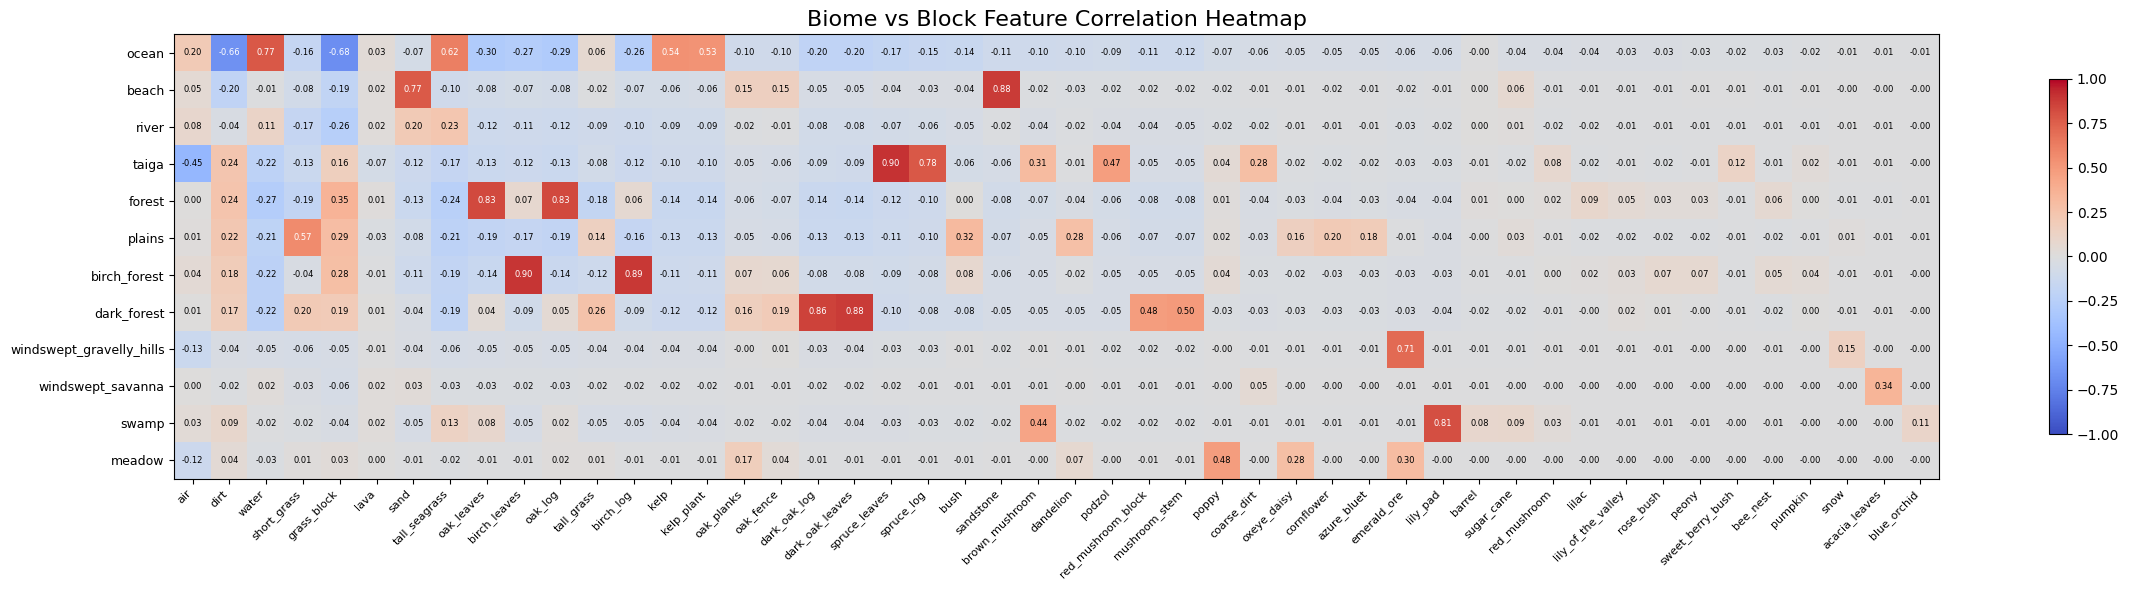

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Encode dominant_biome as numeric for correlation
biome_encoded = data_frame["dominant_biome"].astype("category").cat.codes

# Compute correlation of each block with each biome (one-hot encoded)
biomes = data_frame["dominant_biome"].unique()
biome_block_corr = pd.DataFrame(index=biomes, columns=blocks, dtype=float)

for biome in biomes:
    # Create binary column: 1 if this biome, 0 otherwise
    biome_indicator = (data_frame["dominant_biome"] == biome).astype(int)
    for block in blocks:
        biome_block_corr.loc[biome, block] = biome_indicator.corr(data_frame[block])

fig, ax = plt.subplots(figsize=(24, 6))

# Plot heatmap using imshow
im = ax.imshow(
    biome_block_corr.values.astype(float),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

# Add colourbar
fig.colorbar(im, ax=ax, shrink=0.8)

# Annotate each cell with its correlation value
for i in range(len(biomes)):
    for j in range(len(blocks)):
        val = biome_block_corr.iloc[i, j]
        text_colour = "white" if abs(val) > 0.5 else "black"
        ax.text(
            j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=text_colour
        )

# Set tick labels
ax.set_xticks(range(len(blocks)))
ax.set_yticks(range(len(biomes)))
ax.set_xticklabels(blocks, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(biomes, fontsize=9)

ax.set_title("Biome vs Block Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

#### Save the wrangled data to CSV

In [15]:
data_frame.to_csv('../2.2.Feature_Engineering/2.2.1.wrangled_data.csv', index=False)